In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 24

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 24
there are 44 non_grid and non_spatial_cells
there are 23 grid_cells
there are 40 non grid spatial cells
there are 4 non spatial cells
there are 2 speed cells
there are 69 cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Found 4 modules with HDBSCAN for mouse 25 day 24
for each module , the number of points is: [ 1  5  4 13]


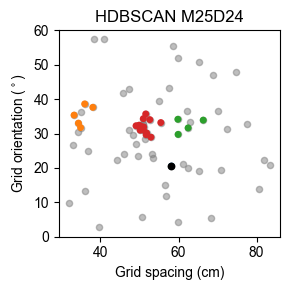

for module 0, there are 5 cells with average spacing 35.305404003465775
for module 1, there are 4 cells with average spacing 62.127313214275674
for module 2, there are 13 cells with average spacing 51.44469907502155
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
25 24
for module 0, there are 5 cells
for module 2, there are 13 cells
for module 1, there are 4 cells


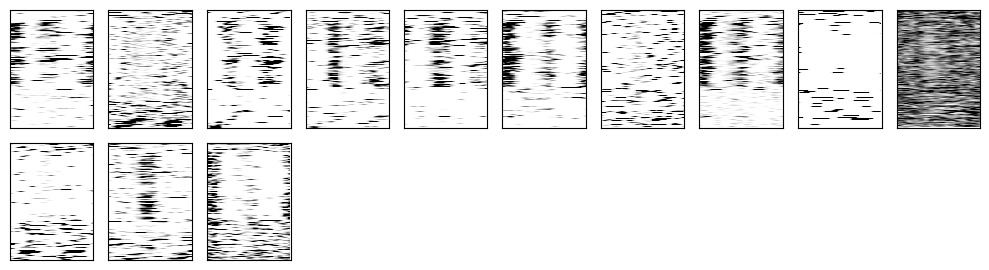

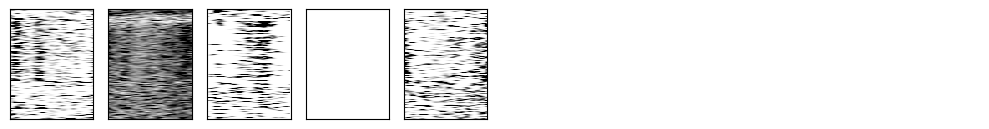

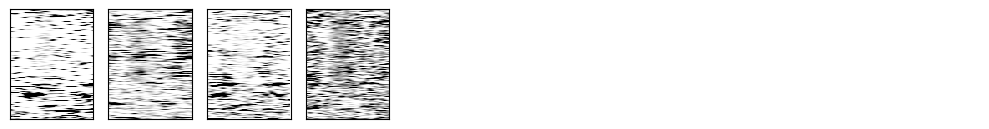

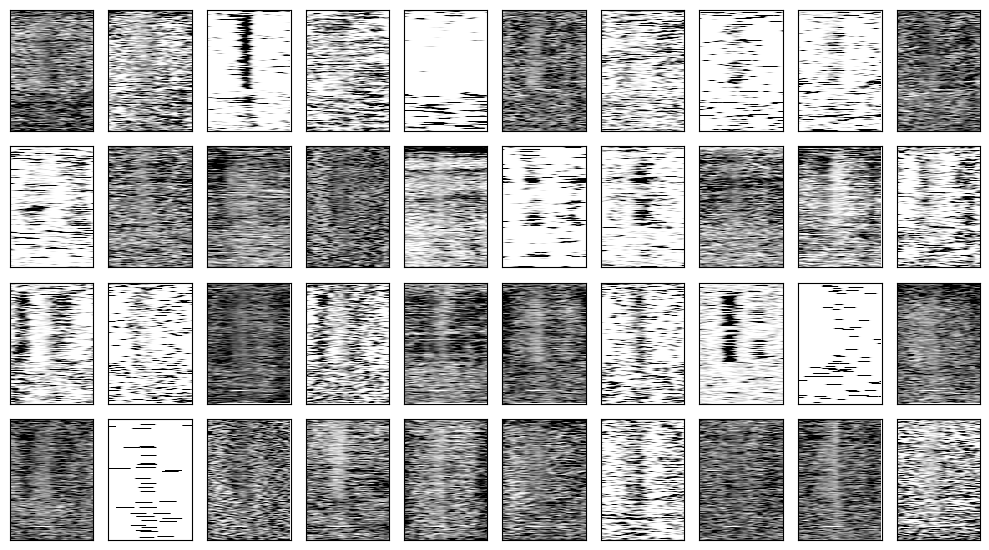

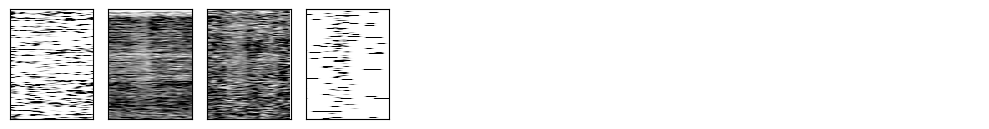

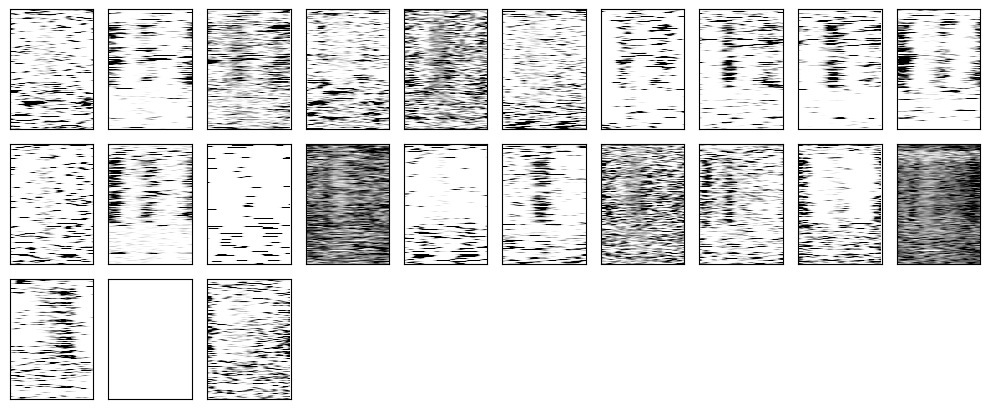

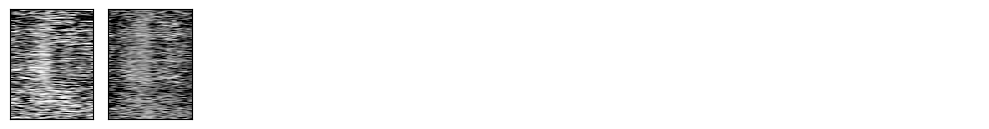

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

#plot_vr_rate_maps(mouse, day, rc.cluster_id.values, label=f'ramp_cells', figpath=fig_path)
#plot_vr_rate_maps(mouse, day, rsc.cluster_id.values, label=f'speed_ramp_cells', figpath=fig_path)

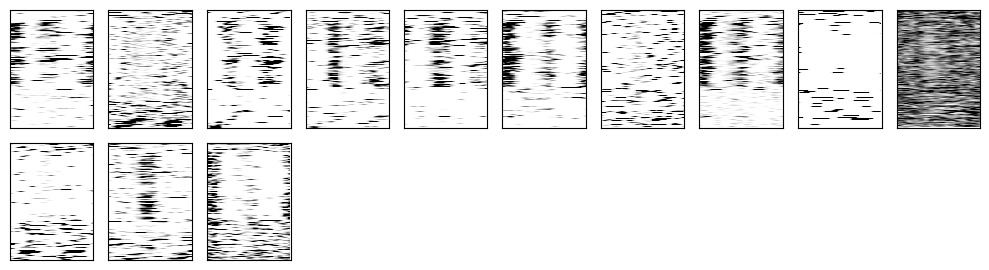

In [4]:
cluster_ids=cluster_ids_by_group[0]
tcs,tcs_time,_,_,_,_ = compute_vr_tcs(mouse, day)
ncols = 10
nrows = int(np.ceil(len(cluster_ids)/ncols))
fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=(10, 1.4*nrows), squeeze=False)
counter = 0
for j in range(nrows):
    for i in range(ncols):
        if counter<len(cluster_ids):
            index = cluster_ids[counter]
            plot_firing_rate_map(ax[j, i], 
                                zscore(tcs[index]),
                                bs=bs,
                                tl=tl,
                                p=95)
        else:
            ax[j, i].axis('off')
        counter+=1
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([])
        ax[j, i].xaxis.set_tick_params(labelbottom=False)
        ax[j, i].yaxis.set_tick_params(labelleft=False)
plt.tight_layout()
plt.show()

/Users/harryclark/Downloads/kilosort4_sa
/Users/harryclark/Downloads/kilosort4_sa


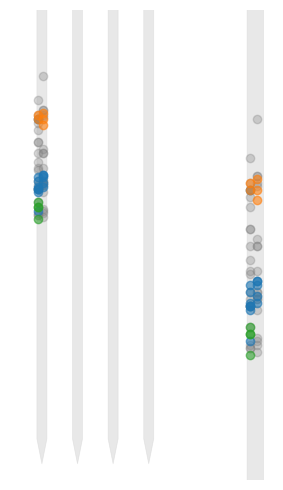

In [5]:

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(4, 5), squeeze=False)
plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
ax[0,0].scatter(ngs['probe_x'], ngs['probe_y'], color='tab:grey', alpha=0.3)
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,0].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6)
ax[0,0].set_xlim(-200, 1000)
ax[0,0].set_ylim(-300, 3000)
plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
ax[0,1].scatter(ngs['probe_x'], ngs['probe_y'], color='tab:grey', alpha=0.3)
for m, cluster_ids in enumerate(g_m_cluster_ids):
    m_gcs = gcs[gcs.cluster_id.isin(cluster_ids)]
    ax[0,1].scatter(m_gcs['probe_x'], m_gcs['probe_y'], alpha=0.6)
ax[0,1].set_xlim([-25, 100])
ax[0,1].set_ylim([1000,3000])
plt.tight_layout()
plt.show()

Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


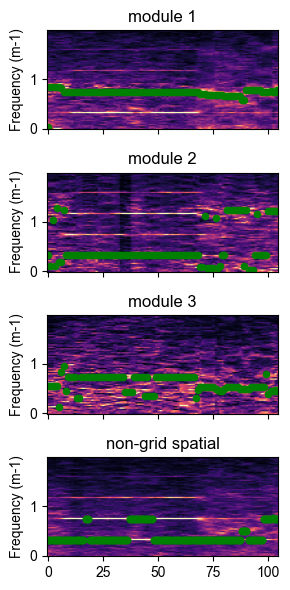

In [ ]:
fig, ax = plt.subplots(nrows=len(g_m_cluster_ids)+1, ncols=1, figsize=(3, 6), squeeze=False, sharex=True)
for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    ax[m,0].set_title(f'module {m+1}')
    ax[m,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[m,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[m,0].set_ylabel(f'Frequency (m-1)')

    #max_peaks = np.argmax(S, axis=0)
    #ax[m,0].scatter(np.arange(len(max_peaks)), max_peaks, color='green', s=20)

    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    ax[-1,0].set_title(f'non-grid spatial')
    ax[-1,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[-1,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[-1,0].set_ylabel(f'Frequency (m-1)')

    #max_peaks = np.argmax(S, axis=0)
    #ax[-1,0].scatter(np.arange(len(max_peaks)), max_peaks, color='green', s=20)
# make a ylabel for the whole y axis
plt.tight_layout()
plt.show()


Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


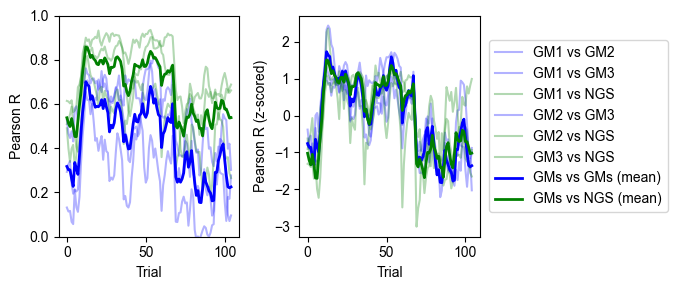

In [69]:
moduleSs= []
labels = ['GM' + str(i+1) for i in range(len(g_m_cluster_ids))] + ['NGS']
for m in range(len(g_m_cluster_ids)):
    cluster_ids = g_m_cluster_ids[m]
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    moduleSs.append(S)
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
S = spectrograms.mean(0)
moduleSs.append(S)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 3), squeeze=False)
gm_vs_gm_corrs = []
gm_vs_ngs_corrs = []

for i in range(len(moduleSs)):
    for j in range(i+1, len(moduleSs)):
        # Set color: blue for GM vs GM, green for GM vs NGS
        if j < len(moduleSs) - 1:
            color = 'blue'
            alpha = 0.3
            corrs_list = gm_vs_gm_corrs
        else:
            color = 'green'
            alpha = 0.3
            corrs_list = gm_vs_ngs_corrs
        # calculate correlation between moduleSs[i] and moduleSs[j] at each time point
        corrs = []
        for t in range(moduleSs[i].shape[1]):
            corrs.append(stats.pearsonr(moduleSs[i].T[t], moduleSs[j].T[t])[0])
        corrs = np.array(corrs)
        ax[0,0].plot(corrs, label=f'{labels[i]} vs {labels[j]}', alpha=alpha, color=color)
        ax[0,1].plot(zscore(corrs), label=f'{labels[i]} vs {labels[j]}', alpha=alpha, color=color)
        corrs_list.append(corrs)

# Plot the average for GM vs GM
if gm_vs_gm_corrs:
    gm_vs_gm_mean = np.mean(gm_vs_gm_corrs, axis=0)
    ax[0,0].plot(gm_vs_gm_mean, label='GMs vs GMs (mean)', color='blue', alpha=1, linewidth=2)
    ax[0,1].plot(zscore(gm_vs_gm_mean), label='GMs vs GMs (mean)', color='blue', alpha=1, linewidth=2)

# Plot the average for GM vs NGS
if gm_vs_ngs_corrs:
    gm_vs_ngs_mean = np.mean(gm_vs_ngs_corrs, axis=0)
    ax[0,0].plot(gm_vs_ngs_mean, label='GMs vs NGS (mean)', color='green', alpha=1, linewidth=2)
    ax[0,1].plot(zscore(gm_vs_ngs_mean), label='GMs vs NGS (mean)', color='green', alpha=1, linewidth=2)

ax[0,0].set_xlabel('Trial')
ax[0,1].set_xlabel('Trial')
ax[0,0].set_ylabel('Pearson R')
ax[0,1].set_ylabel('Pearson R (z-scored)')
ax[0,0].set_ylim(0,1)
plt.tight_layout()
# Place legend outside the right of the last axis
ax[0,1].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), borderaxespad=0.)
plt.show()


Identified 1 candidate modules


IndexError: list index out of range

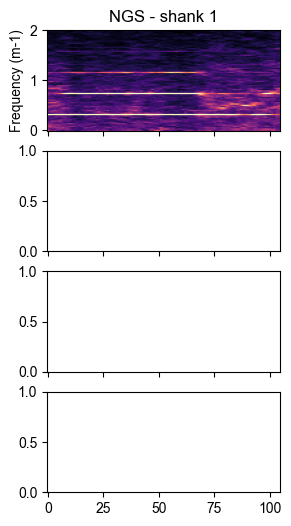

In [7]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(3, 6), squeeze=False, sharex=True)
for s in [0,1,2,3]:
    shank_ngs = ngs[(ngs.probe_x >= (s*250)) & (ngs.probe_x <= (50+(s*250)))]
    cluster_ids = shank_ngs.cluster_id.values
    tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
    results = spectral_analysis(tcs_to_use, tl, bs=bs)
    spectrograms = results[3] 
    S = spectrograms.mean(0)
    ax[s,0].set_title(f'NGS - shank {s+1}')
    ax[s,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
    ax[s,0].set_yticks([0, len(S)/2, len(S)], [0, 1, 2])
    ax[s,0].set_ylabel(f'Frequency (m-1)')

# make a ylabel for the whole y axis
plt.tight_layout()
plt.show()
